# LAB - 6


Running Pix2Pix on: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.35MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]


Starting Pix2Pix Training...
Epoch 1/20 [D loss: 0.0771] [G loss: 25.5448]
Epoch 2/20 [D loss: 0.2899] [G loss: 13.0472]
Epoch 3/20 [D loss: 0.4267] [G loss: 12.1765]
Epoch 4/20 [D loss: 0.0971] [G loss: 14.0654]
Epoch 5/20 [D loss: 0.4660] [G loss: 11.5031]
Epoch 6/20 [D loss: 0.2059] [G loss: 11.4180]
Epoch 7/20 [D loss: 0.1630] [G loss: 11.9194]
Epoch 8/20 [D loss: 0.1113] [G loss: 12.0608]
Epoch 9/20 [D loss: 0.6504] [G loss: 12.6458]
Epoch 10/20 [D loss: 0.0121] [G loss: 15.1173]
Epoch 11/20 [D loss: 0.0736] [G loss: 21.5689]
Epoch 12/20 [D loss: 0.3791] [G loss: 8.9108]
Epoch 13/20 [D loss: 0.0821] [G loss: 11.0608]
Epoch 14/20 [D loss: 0.1102] [G loss: 9.6587]
Epoch 15/20 [D loss: 0.0167] [G loss: 18.6611]
Epoch 16/20 [D loss: 0.0545] [G loss: 12.8859]
Epoch 17/20 [D loss: 0.1260] [G loss: 10.3148]
Epoch 18/20 [D loss: 0.0310] [G loss: 12.7910]
Epoch 19/20 [D loss: 0.0090] [G loss: 29.8444]
Epoch 20/20 [D loss: 0.0072] [G loss: 18.8994]


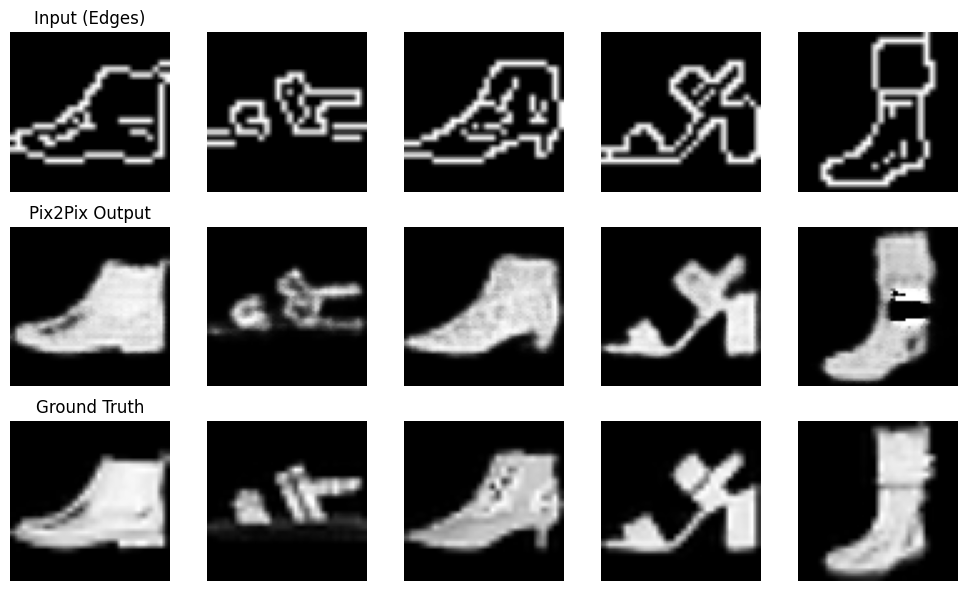

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import cv2


BATCH_SIZE = 64
EPOCHS = 20
LR = 0.0002
LAMBDA_L1 = 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Running Pix2Pix on: {DEVICE}")


class SimulatedEdges2ShoesDataset(Dataset):
    def __init__(self, root='./data', train=True):
        self.transform = transforms.Compose([
            transforms.Resize(64),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        full_ds = torchvision.datasets.FashionMNIST(root=root, train=train, download=True)
        self.data = [img for img, label in full_ds if label in [5, 7, 9]]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        real_img_pil = self.data[idx]


        real_img = self.transform(real_img_pil)


        img_np = np.array(real_img_pil)
        edges = cv2.Canny(img_np, 100, 200)
        edges = transforms.ToPILImage()(edges)
        edge_img = self.transform(edges)

        return edge_img, real_img

train_ds = SimulatedEdges2ShoesDataset(train=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)


class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        self.enc1 = self.conv_block(1, 64, bn=False)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 512)

        self.dec4 = self.up_block(512, 512, dropout=True)
        self.dec3 = self.up_block(1024, 256)
        self.dec2 = self.up_block(512, 128)
        self.dec1 = self.up_block(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def conv_block(self, in_c, out_c, bn=True):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if bn: layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=False):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout: layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.dec4(b)
        d4 = torch.cat((d4, e4), dim=1)

        d3 = self.dec3(d4)
        d3 = torch.cat((d3, e3), dim=1)

        d2 = self.dec2(d3)
        d2 = torch.cat((d2, e2), dim=1)

        d1 = self.dec1(d2)
        d1 = torch.cat((d1, e1), dim=1)

        return self.final(d1)


class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        # Convolutional layers with no fully connected layers [cite: 449-450]
        self.model = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Output patch-level authenticity map [cite: 451]
            nn.Conv2d(256, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, img_A, img_B):
        x = torch.cat((img_A, img_B), 1)
        return self.model(x)


generator = UNetGenerator().to(DEVICE)
discriminator = PatchGANDiscriminator().to(DEVICE)


optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))


adversarial_loss = nn.BCELoss()
l1_loss = nn.L1Loss()

print("Starting Pix2Pix Training...")

for epoch in range(EPOCHS):
    for i, (edge_img, real_img) in enumerate(train_loader):

        edge_img = edge_img.to(DEVICE)
        real_img = real_img.to(DEVICE)


        valid = torch.ones((edge_img.size(0), 1, 7, 7), device=DEVICE)
        fake = torch.zeros((edge_img.size(0), 1, 7, 7), device=DEVICE)

        # ------------------
        #  Train Generator
        # ------------------
        optimizer_G.zero_grad()
        fake_img = generator(edge_img)
        pred_fake = discriminator(edge_img, fake_img)

        loss_GAN = adversarial_loss(pred_fake, valid)
        loss_pixel = l1_loss(fake_img, real_img)
        loss_G = loss_GAN + (LAMBDA_L1 * loss_pixel)

        loss_G.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        pred_real = discriminator(edge_img, real_img)
        loss_real = adversarial_loss(pred_real, valid)

        pred_fake = discriminator(edge_img, fake_img.detach())
        loss_fake = adversarial_loss(pred_fake, fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    print(f"Epoch {epoch+1}/{EPOCHS} [D loss: {loss_D.item():.4f}] [G loss: {loss_G.item():.4f}]")


generator.eval()
test_dl = DataLoader(train_ds, batch_size=5, shuffle=True)
edge_sample, real_sample = next(iter(test_dl))
edge_sample = edge_sample.to(DEVICE)

with torch.no_grad():
    fake_sample = generator(edge_sample).cpu()

fig, axs = plt.subplots(3, 5, figsize=(10, 6))
for i in range(5):
    axs[0, i].imshow(edge_sample[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    if i==0: axs[0,i].set_title("Input (Edges)")

    axs[1, i].imshow(fake_sample[i].squeeze(), cmap='gray')
    axs[1, i].axis('off')
    if i==0: axs[1,i].set_title("Pix2Pix Output")

    axs[2, i].imshow(real_sample[i].squeeze(), cmap='gray')
    axs[2, i].axis('off')
    if i==0: axs[2,i].set_title("Ground Truth")

plt.tight_layout()
plt.show()